<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Conteo_de_Manzanas_con_Detectron2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyyaml

In [2]:
!git clone 'https://github.com/facebookresearch/detectron2'

Cloning into 'detectron2'...
remote: Enumerating objects: 16057, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 16057 (delta 25), reused 8 (delta 8), pack-reused 16016 (from 3)
Receiving objects: 100% (16057/16057), 6.83 MiB | 11.17 MiB/s, done.
Resolving deltas: 100% (11377/11377), done.


In [3]:
import sys, os, distutils.core

dist = distutils.core.run_setup("./detectron2/setup.py")

In [4]:
!python -m pip install {' '.join([f"'{x}'" for x in dist.install_requires])}
sys.path.insert(0, os.path.abspath('./detectron2'))

Ignoring dataclasses: markers 'python_version < "3.7"' don't match your environment
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.8/155.8 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.4/268.4 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 16.1 MB/s eta 0:00:00
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=087d7342daf26eb574527b801215ca0f4d9f13abebc52c1f35c07e4e628baf4d
  Stored in directory: /root/.cache/pip/wheels/6b/1b/9a/9f4843148961a522f56dbeaa5543071ac2389d9a079ec724ab
Successfully built fvcore


In [5]:
import torch, detectron2
!nvcc --version
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]
print("torch: ", TORCH_VERSION, "; cuda: ", CUDA_VERSION)
print("detectron2:", detectron2.__version__)

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
torch:  2.11 ; cuda:  cu128
detectron2: 0.6


In [6]:
import cv2
import torch
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog

Imagen descargada con éxito como: estanteria_manzanas.jpg


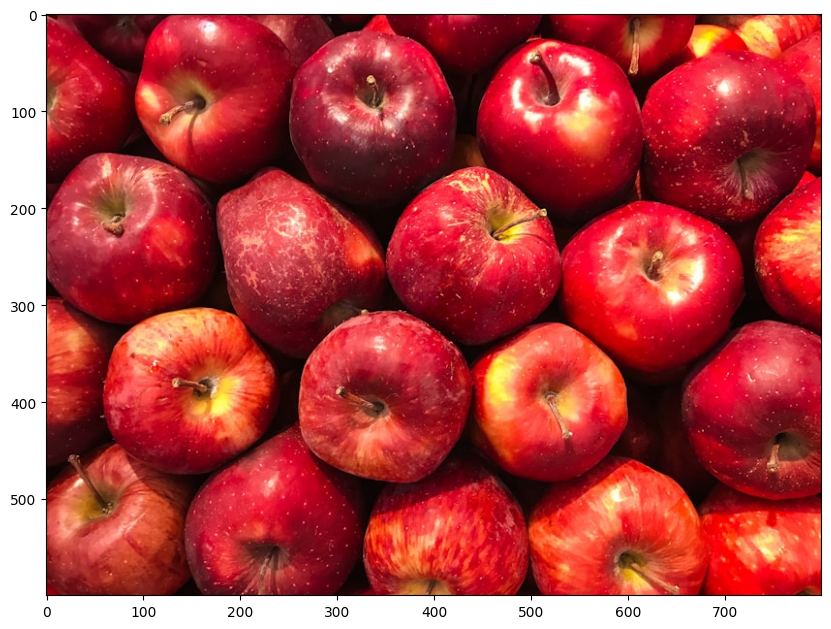

In [7]:
# URL de una imagen pública de manzanas en un anaquel
url_imagen = "https://images.unsplash.com/photo-1560806887-1e4cd0b6cbd6?w=800"
image_path = "estanteria_manzanas.jpg"

# Descargar la imagen a tu entorno local
urllib.request.urlretrieve(url_imagen, image_path)
print("Imagen descargada con éxito como:", image_path)

cv2_img = cv2.imread(image_path)
cv2_rgb = cv2.cvtColor(cv2_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(cv2_rgb)

In [8]:
# CONFIGURAR DETECTRON2
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # Filtrar por 50% de confianza
cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

predictor = DefaultPredictor(cfg)

model_final_f10217.pkl: 178MB [00:01, 156MB/s]                           


In [9]:
# CARGAR Y PROCESAR LA IMAGEN
im = cv2.imread(image_path)
outputs = predictor(im)

# EXTRAER Y FILTRAR SOLO MANZANAS (Clase COCO 47 = "apple")
instances = outputs["instances"].to("cpu")
clases = instances.pred_classes
ID_MANZANA = 47

/usr/local/lib/python3.13/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0826 13:47:29.794000 939 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


In [10]:
# Crear máscara de selección para conservar únicamente manzanas
mask_manzanas = (clases == ID_MANZANA)
manzanas_instances = instances[mask_manzanas]

total_manzanas = len(manzanas_instances)
print(f"\n--- RESULTADO DEL INVENTARIO ---")
print(f"Manzanas detectadas en el anaquel: {total_manzanas}")


--- RESULTADO DEL INVENTARIO ---
Manzanas detectadas en el anaquel: 23


Resultado visual guardado como: inventario_procesado.jpg


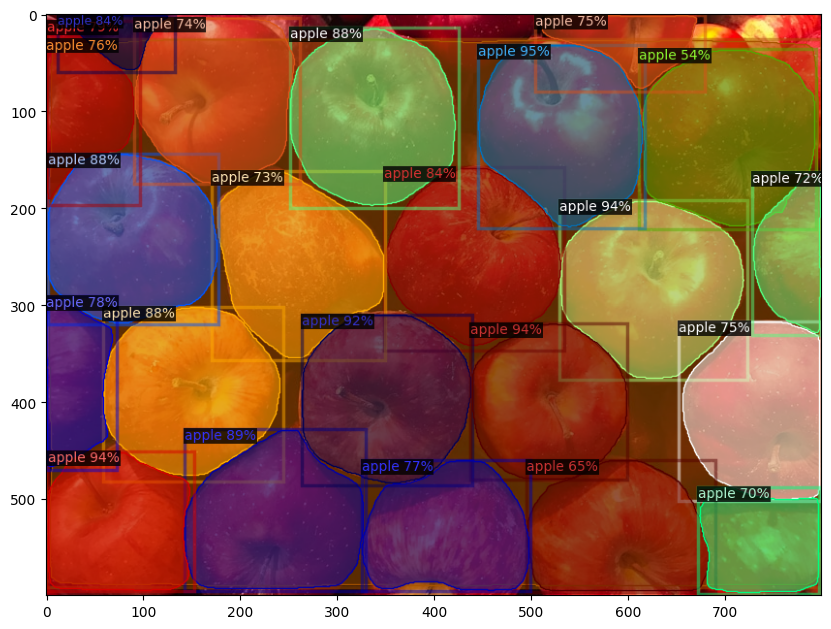

In [11]:
# VISUALIZAR Y GUARDAR
v = Visualizer(
    im[:, :, ::-1],
    metadata=MetadataCatalog.get(cfg.DATASETS.TRAIN[0]),
    scale=1.0
)

# Dibujar únicamente las manzanas segmentadas
out = v.draw_instance_predictions(manzanas_instances)

cv2_rgb = cv2.cvtColor(out.get_image()[:, :, ::-1], cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 10))
plt.imshow(cv2_rgb)

# Guardar la imagen con las máscaras dibujadas
resultado_path = "inventario_procesado.jpg"
cv2.imwrite(resultado_path, out.get_image()[:, :, ::-1])
print("Resultado visual guardado como:", resultado_path)